# NLP – 4 (BERT Fine-Tuning)
Dataset = IMDB Movie Reviews from Kaggle

In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [2]:
import kagglehub
import pandas as pd

# 1. Download the 50k Reviews dataset (Standard for BERT training)
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# 2. Load the CSV (kagglehub returns the folder path, so we append the filename)
# Usually, the file is named 'IMDB Dataset.csv'
df = pd.read_csv(f"{path}/IMDB Dataset.csv")

# 3. Quick Preprocessing for BERT
# Map 'positive' to 1 and 'negative' to 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df = df.rename(columns={'review': 'text'})

print(df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                                text sentiment  label
0  One of the other reviewers has mentioned that ...  positive      1
1  A wonderful little production. <br /><br />The...  positive      1
2  I thought this was a wonderful way to spend ti...  positive      1
3  Basically there's a family where a little boy ...  negative      0
4  Petter Mattei's "Love in the Time of Money" is...  positive      1


In [3]:
import torch
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate

# 1. Load the ur Kaggle Dataset

# 2. Split Data (80/10/10)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

# Convert to Hugging Face Dataset format
ds = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

In [4]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_datasets = ds.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Load Model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
def prepare_experiment(model, mode="full"):
    if mode == "frozen":
        # Freeze ALL BERT layers
        for param in model.bert.parameters():
            param.requires_grad = False
    elif mode == "last_two":
        # Freeze all except last 2 layers
        for param in model.bert.encoder.layer[:-2].parameters():
            param.requires_grad = False
    return model

# Example: Run the "last two layers" experiment
model = prepare_experiment(model, mode="last_two")

In [6]:
# 1. Define the metrics
metric = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 2. Set up training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",      # Ensure this is 'eval_strategy'
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# 3. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,      # The tokenizer is already inside here
    compute_metrics=compute_metrics,
)

# 4. Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.305988,0.329396,0.859400,0.847737,0.924858,0.782487
2,0.269965,0.287494,0.883400,0.887560,0.857303,0.920032
3,0.230407,0.293271,0.889200,0.890297,0.881914,0.898840


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7500, training_loss=0.28142657165527346, metrics={'train_runtime': 2210.4657, 'train_samples_per_second': 54.287, 'train_steps_per_second': 3.393, 'total_flos': 7893331660800000.0, 'train_loss': 0.28142657165527346, 'epoch': 3.0})

Final Test Metrics: {'test_loss': 0.2901322841644287, 'test_accuracy': 0.8788, 'test_f1': 0.883819018404908, 'test_precision': 0.8607169529499626, 'test_recall': 0.9081954294720253, 'test_runtime': 38.6682, 'test_samples_per_second': 129.305, 'test_steps_per_second': 16.163}


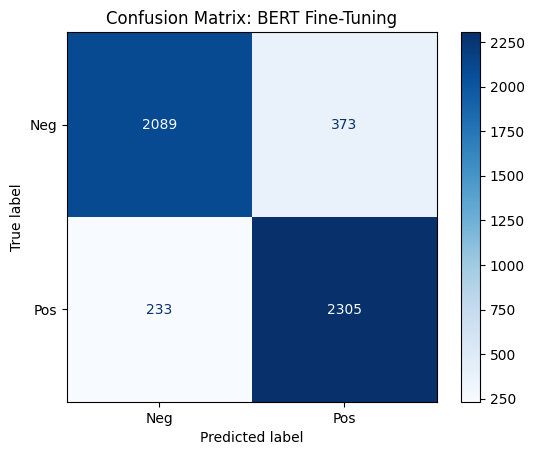

In [7]:
# Get predictions on the Test set
predictions = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Print Final Metrics
print(f"Final Test Metrics: {predictions.metrics}")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Neg", "Pos"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: BERT Fine-Tuning")
plt.show()